# data preprocessing 
## we will start with one csv inspect check for other then combine the best 


1. Load & basic structure check

In [19]:
import pandas as pd
import numpy as np

csv_path = "/kaggle/input/data-analytics-full-dataset/fulldataset.csv"
df = pd.read_csv(csv_path)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Shape: (2872533, 55)

Columns:
['timestamp', 'activity_id', 'heart_rate', 'hand_temp', 'hand_acc16_x', 'hand_acc16_y', 'hand_acc16_z', 'hand_acc6_x', 'hand_acc6_y', 'hand_acc6_z', 'hand_gyro_x', 'hand_gyro_y', 'hand_gyro_z', 'hand_mag_x', 'hand_mag_y', 'hand_mag_z', 'hand_orient_1', 'hand_orient_2', 'hand_orient_3', 'hand_orient_4', 'chest_temp', 'chest_acc16_x', 'chest_acc16_y', 'chest_acc16_z', 'chest_acc6_x', 'chest_acc6_y', 'chest_acc6_z', 'chest_gyro_x', 'chest_gyro_y', 'chest_gyro_z', 'chest_mag_x', 'chest_mag_y', 'chest_mag_z', 'chest_orient_1', 'chest_orient_2', 'chest_orient_3', 'chest_orient_4', 'ankle_temp', 'ankle_acc16_x', 'ankle_acc16_y', 'ankle_acc16_z', 'ankle_acc6_x', 'ankle_acc6_y', 'ankle_acc6_z', 'ankle_gyro_x', 'ankle_gyro_y', 'ankle_gyro_z', 'ankle_mag_x', 'ankle_mag_y', 'ankle_mag_z', 'ankle_orient_1', 'ankle_orient_2', 'ankle_orient_3', 'ankle_orient_4', 'subject_id']


2. check missing values

In [2]:
missing = df.isna().sum()
missing = missing[missing > 0]

print("Missing values per column:")
print(missing)


Missing values per column:
heart_rate        2610265
hand_temp           13141
hand_acc16_x        13141
hand_acc16_y        13141
hand_acc16_z        13141
hand_acc6_x         13141
hand_acc6_y         13141
hand_acc6_z         13141
hand_gyro_x         13141
hand_gyro_y         13141
hand_gyro_z         13141
hand_mag_x          13141
hand_mag_y          13141
hand_mag_z          13141
hand_orient_1       13141
hand_orient_2       13141
hand_orient_3       13141
hand_orient_4       13141
chest_temp           3563
chest_acc16_x        3563
chest_acc16_y        3563
chest_acc16_z        3563
chest_acc6_x         3563
chest_acc6_y         3563
chest_acc6_z         3563
chest_gyro_x         3563
chest_gyro_y         3563
chest_gyro_z         3563
chest_mag_x          3563
chest_mag_y          3563
chest_mag_z          3563
chest_orient_1       3563
chest_orient_2       3563
chest_orient_3       3563
chest_orient_4       3563
ankle_temp          11749
ankle_acc16_x       11749
ankle_acc16

* Heart rate has very high missing values (~2.6M), which means many rows have no heart rate.

* Other sensors have smaller but non-zero missing counts.

* Chest sensors have only a few thousand missing values.

3. activity distribution 


activity_id
0     929661
1     192523
2     185188
3     189931
4     238761
5      98199
6     164600
7     188107
12    117216
13    104944
16    175353
17    238690
24     49360
Name: count, dtype: int64


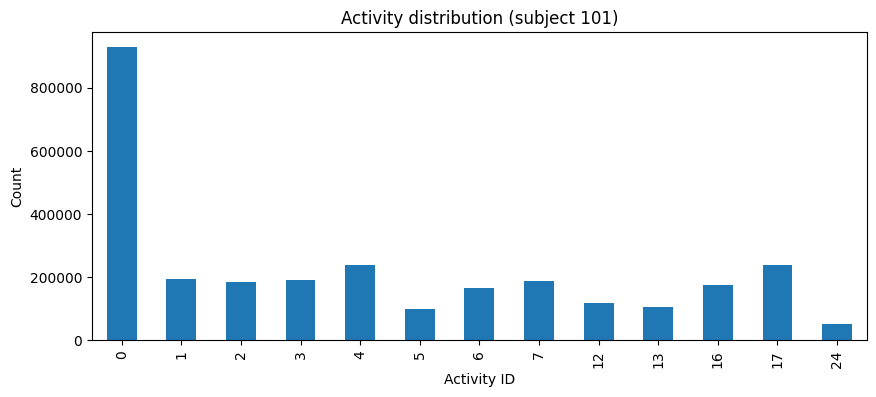

In [3]:
activity_counts = df["activity_id"].value_counts().sort_index()

print(activity_counts)

import matplotlib.pyplot as plt
activity_counts.plot(kind="bar", figsize=(10,4))
plt.title("Activity distribution (subject 101)")
plt.xlabel("Activity ID")
plt.ylabel("Count")
plt.show()


* Some activities (0, 1, 2…) are heavily imbalanced: Activity 0 has ~930k rows, activity 24 only ~49k.

-> we need to account for class imbalance when training later (sampling, weighting, or augmentation).

4. timestamp sanity check(time series integrity) 


In [4]:
print("Timestamp monotonic:", df["timestamp"].is_monotonic_increasing)

dt = df["timestamp"].diff().dropna()
print("Sampling interval stats:")
print(dt.describe())


Timestamp monotonic: False
Sampling interval stats:
count    2.872532e+06
mean     3.292914e-05
std      6.044476e+00
min     -4.469740e+03
25%      1.000000e-02
50%      1.000000e-02
75%      1.000000e-02
max      1.000000e-02
Name: timestamp, dtype: float64


* Timestamp is not monotonic, some negative or out-of-order intervals.

* Mean sampling interval is tiny (~3.3e-5), but some intervals are negative.

5. sensor value ranges(detect broken channels) 


In [5]:
sensor_cols = [c for c in df.columns if c not in ["timestamp", "activity_id", "heart_rate"]]

df[sensor_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
hand_temp,2859392.0,32.652579,1.844274,24.750000,31.437500,33.125000,34.000000,35.500000
hand_acc16_x,2859392.0,-4.960786,5.985029,-145.367000,-9.028420,-5.788145,-0.782942,62.859600
hand_acc16_y,2859392.0,3.587758,6.277838,-104.301000,1.290268,3.570830,6.602720,155.699000
hand_acc16_z,2859392.0,3.168417,3.843923,-101.452000,0.968582,2.958415,6.002930,157.760000
hand_acc6_x,2859392.0,-4.889420,5.992726,-61.489500,-8.933270,-5.737615,-0.724992,52.821400
hand_acc6_y,2859392.0,3.584267,6.055750,-61.868000,1.284680,3.613430,6.601960,62.259800
hand_acc6_z,2859392.0,3.349479,3.840650,-61.934700,1.164040,3.132855,6.257612,61.944600
hand_gyro_x,2859392.0,-0.003705,1.297393,-28.135400,-0.347717,-0.006161,0.302832,26.415800
hand_gyro_y,2859392.0,0.032135,0.887018,-22.212700,-0.197040,0.006133,0.236764,23.077900
hand_gyro_z,2859392.0,-0.006168,1.452335,-16.699700,-0.301137,-0.005327,0.292780,14.338400


* Some outliers exist might want to apply extreme filtering later

6. zero-variance & near-zero features 



In [6]:
variances = df[sensor_cols].var()

zero_var = variances[variances == 0]
low_var = variances[variances < 1e-6]

print("Zero variance columns:")
print(zero_var.index.tolist())

print("\nNear-zero variance columns:")
print(low_var.index.tolist())


Zero variance columns:
[]

Near-zero variance columns:
[]


7. orientation validity check 


In [7]:
# based on recommendation dropped the ±6g channels,
import pandas as pd

# Drop orientation (invalid)
orient_cols = [c for c in df.columns if "orient" in c]

# Drop ±6g accelerometer
acc6_cols = [c for c in df.columns if "acc6" in c]

print("Dropping orientation columns:", orient_cols)
print("Dropping ±6g accelerometer columns:", acc6_cols)

df_clean = df.drop(columns=orient_cols + acc6_cols)

print("New shape:", df_clean.shape)
print("Remaining columns:")
print(df_clean.columns.tolist())


Dropping orientation columns: ['hand_orient_1', 'hand_orient_2', 'hand_orient_3', 'hand_orient_4', 'chest_orient_1', 'chest_orient_2', 'chest_orient_3', 'chest_orient_4', 'ankle_orient_1', 'ankle_orient_2', 'ankle_orient_3', 'ankle_orient_4']
Dropping ±6g accelerometer columns: ['hand_acc6_x', 'hand_acc6_y', 'hand_acc6_z', 'chest_acc6_x', 'chest_acc6_y', 'chest_acc6_z', 'ankle_acc6_x', 'ankle_acc6_y', 'ankle_acc6_z']
New shape: (2872533, 34)
Remaining columns:
['timestamp', 'activity_id', 'heart_rate', 'hand_temp', 'hand_acc16_x', 'hand_acc16_y', 'hand_acc16_z', 'hand_gyro_x', 'hand_gyro_y', 'hand_gyro_z', 'hand_mag_x', 'hand_mag_y', 'hand_mag_z', 'chest_temp', 'chest_acc16_x', 'chest_acc16_y', 'chest_acc16_z', 'chest_gyro_x', 'chest_gyro_y', 'chest_gyro_z', 'chest_mag_x', 'chest_mag_y', 'chest_mag_z', 'ankle_temp', 'ankle_acc16_x', 'ankle_acc16_y', 'ankle_acc16_z', 'ankle_gyro_x', 'ankle_gyro_y', 'ankle_gyro_z', 'ankle_mag_x', 'ankle_mag_y', 'ankle_mag_z', 'subject_id']


* Dropped orientation columns (hand/chest/ankle) and ±6g accelerometer readings.

* Remaining dataset is 34 columns, mostly ±16g accelerometers, gyro, mag, temp, heart_rate, subject_id.

In [8]:
orient_cols = [c for c in df.columns if "orient" in c]

df[orient_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
hand_orient_1,2859392.0,0.566583,0.305388,-0.452246,0.300076,0.586973,0.823650,1.000000
hand_orient_2,2859392.0,-0.056374,0.378051,-0.999996,-0.355064,0.000000,0.219752,0.999943
hand_orient_3,2859392.0,-0.138728,0.335507,-0.998261,-0.413243,-0.137311,0.065226,0.988827
hand_orient_4,2859392.0,-0.032537,0.553853,-0.999326,-0.560345,0.000000,0.431541,0.999677
chest_orient_1,2868970.0,0.532322,0.289489,-0.222089,0.306041,0.512092,0.711348,1.000000
chest_orient_2,2868970.0,-0.407034,0.294558,-0.999467,-0.640591,-0.468676,-0.160864,0.999270
chest_orient_3,2868970.0,0.055154,0.476335,-0.999635,-0.358714,0.000000,0.522882,0.996864
chest_orient_4,2868970.0,0.048559,0.384828,-0.880195,-0.248183,0.027460,0.395102,0.900442
ankle_orient_1,2860784.0,0.398642,0.303456,-0.253628,0.156344,0.319755,0.579442,1.000000
ankle_orient_2,2860784.0,0.021548,0.569130,-0.956876,-0.583991,0.000000,0.627945,0.959538


8. binary flag columns detection 


In [9]:
binary_cols = []

for c in df.columns:
    unique_vals = df[c].dropna().unique()
    if set(unique_vals).issubset({0,1}):
        binary_cols.append(c)

print("Binary columns:")
print(binary_cols)


Binary columns:
[]


* None detected.

* No need for special handling of true/false flags.

9. correlation check 

In [10]:
corr = df[sensor_cols].corr()

high_corr = [
    (c1, c2)
    for c1 in corr.columns
    for c2 in corr.columns
    if c1 != c2 and abs(corr.loc[c1, c2]) > 0.95
]

print("Highly correlated pairs (>0.95):")
print(high_corr[:10])


Highly correlated pairs (>0.95):
[('hand_acc16_x', 'hand_acc6_x'), ('hand_acc16_y', 'hand_acc6_y'), ('hand_acc16_z', 'hand_acc6_z'), ('hand_acc6_x', 'hand_acc16_x'), ('hand_acc6_y', 'hand_acc16_y'), ('hand_acc6_z', 'hand_acc16_z'), ('chest_acc16_x', 'chest_acc6_x'), ('chest_acc16_y', 'chest_acc6_y'), ('chest_acc16_z', 'chest_acc6_z'), ('chest_acc6_x', 'chest_acc16_x')]


# STEP 1 Remove transient activity (activity_id = 0)
18 activity classes excluding transient

In [12]:
# Drop transient activity (ID = 0)
df = df[df['activity_id'] != 0]

# Check new activity distribution
activity_counts = df['activity_id'].value_counts()
print("Updated activity counts:\n", activity_counts)


Updated activity counts:
 activity_id
4     238761
17    238690
1     192523
3     189931
7     188107
2     185188
16    175353
6     164600
12    117216
13    104944
5      98199
24     49360
Name: count, dtype: int64


# STEP 2 check and handle class imbalance

we will use class weights in our model:

* this will guarantees minority classes aren’t ignored.

* Works with tree-based models (XGBoost, LightGBM) and deep learning (PyTorch, Keras).

Activity counts:
 activity_id
1     192523
2     185188
3     189931
4     238761
5      98199
6     164600
7     188107
12    117216
13    104944
16    175353
17    238690
24     49360
Name: count, dtype: int64
Class weights:
 {np.int64(1): np.float64(0.8409696503794352), np.int64(2): np.float64(0.8742791109575134), np.int64(3): np.float64(0.85244641475062), np.int64(4): np.float64(0.6781090714145107), np.int64(5): np.float64(1.648754060631982), np.int64(6): np.float64(0.98363304981774), np.int64(7): np.float64(0.8607122541957503), np.int64(12): np.float64(1.3812619437619438), np.int64(13): np.float64(1.542784723280988), np.int64(16): np.float64(0.9233146852349261), np.int64(17): np.float64(0.6783107796723784), np.int64(24): np.float64(3.2801053484602916)}


/tmp/ipykernel_55/2733585876.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=activity_counts.index, y=activity_counts.values, palette='coolwarm')


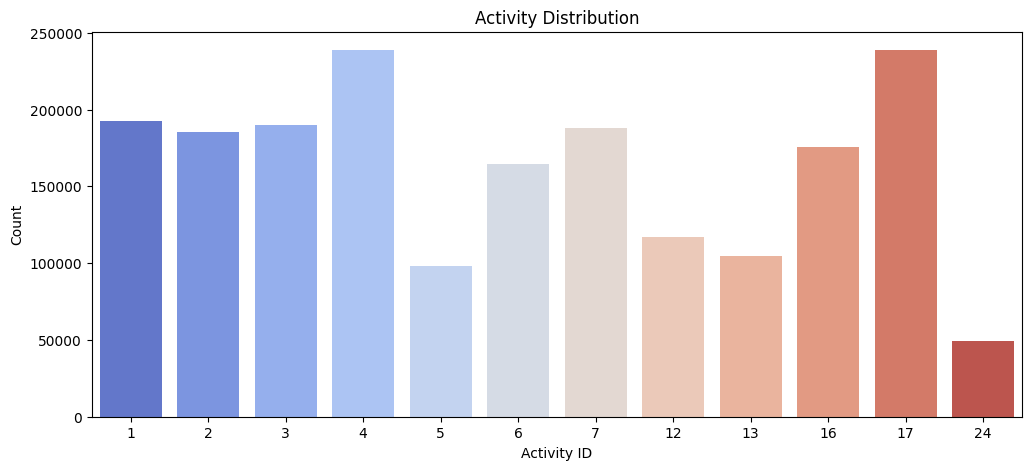

In [13]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compute activity counts
activity_counts = df['activity_id'].value_counts().sort_index()
print("Activity counts:\n", activity_counts)

# 2. Compute class weights
activities = np.array(sorted(df['activity_id'].unique()))
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=activities,
    y=df['activity_id']
)
class_weight_dict = dict(zip(activities, class_weights))
print("Class weights:\n", class_weight_dict)

# 3. Visualize imbalance
plt.figure(figsize=(12,5))
sns.barplot(x=activity_counts.index, y=activity_counts.values, palette='coolwarm')
plt.title("Activity Distribution")
plt.xlabel("Activity ID")
plt.ylabel("Count")
plt.show()


We keep the dataset as is (we already dropped the transient class 0).

We don’t touch or balance the data manually.

We use the class weights we computed to tell the model:

“Pay more attention to rare classes, less to common ones.”

# STEP 3 fix the timestamp issues
each subject’s data is in proper chronological order. Since this is a time-series dataset, sorting by subject_id and timestamp is essential.

In [14]:
# 1. Sort the dataset by subject_id and timestamp
df_sorted = df.sort_values(by=['subject_id', 'timestamp']).reset_index(drop=True)

# 2. Check for negative or zero intervals (optional, for sanity)
df_sorted['time_diff'] = df_sorted.groupby('subject_id')['timestamp'].diff()
negative_intervals = (df_sorted['time_diff'] <= 0).sum()
print(f"Number of non-monotonic intervals after sorting: {negative_intervals}")

# 3. (Optional) Remove duplicate timestamps per subject
df_sorted = df_sorted.drop_duplicates(subset=['subject_id', 'timestamp'])

# 4. Drop the temporary column if you want
df_sorted = df_sorted.drop(columns=['time_diff'])

# Now df_sorted is ready for time-series processing
print(df_sorted.head())


Number of non-monotonic intervals after sorting: 0
   timestamp  activity_id  heart_rate  hand_temp  hand_acc16_x  hand_acc16_y  \
0      37.66            1         NaN     30.375       2.21530       8.27915   
1      37.67            1         NaN     30.375       2.29196       7.67288   
2      37.68            1         NaN     30.375       2.29090       7.14240   
3      37.69            1         NaN     30.375       2.21800       7.14365   
4      37.70            1       100.0     30.375       2.30106       7.25857   

   hand_acc16_z  hand_acc6_x  hand_acc6_y  hand_acc6_z  ...  ankle_gyro_y  \
0       5.58753      2.24689      8.55387      5.77143  ...     -0.027714   
1       5.74467      2.27373      8.14592      5.78739  ...      0.000945   
2       5.82342      2.26966      7.66268      5.78846  ...     -0.052422   
3       5.89930      2.22177      7.25535      5.88000  ...     -0.018844   
4       6.09259      2.20720      7.24042      5.95555  ...     -0.048878   

   an

# STEP 4 sensor value sanity
Since most sensors are fine but a few extreme outliers exist, we can clip values to reasonable min/max ranges. This avoids letting extreme spikes distort our model.

In [15]:
import numpy as np

# List of sensor columns to clip (excluding timestamps, activity_id, subject_id)
sensor_cols = df.columns.difference(['timestamp', 'activity_id', 'subject_id'])

# Clip each sensor at 1st and 99th percentile
for col in sensor_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

# Check min/max after clipping
df[sensor_cols].describe().T[['min', 'max']]


,min,max
ankle_acc16_x,-1.861120,28.009336
ankle_acc16_y,-18.085516,27.197172
ankle_acc16_z,-13.376536,6.955965
ankle_acc6_x,-1.699299,27.780588
ankle_acc6_y,-17.440352,26.767668
ankle_acc6_z,-12.624836,6.757906
ankle_gyro_x,-3.402939,3.613208
ankle_gyro_y,-2.331451,1.630941
ankle_gyro_z,-5.197787,6.794870
ankle_mag_x,-85.452400,5.288364


# Step 5 handling missing values

In [17]:
import pandas as pd

# Assuming your DataFrame is named `df`
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

# Combine count and percentage in a DataFrame for readability
missing_summary = pd.DataFrame({
    'missing_count': missing_values,
    'missing_percent': missing_percent
}).sort_values(by='missing_count', ascending=False)

print("Missing values per column:")
print(missing_summary)


Missing values per column:
                missing_count  missing_percent
heart_rate            1765464        90.868776
hand_acc16_x            11124         0.572554
hand_temp               11124         0.572554
hand_acc16_y            11124         0.572554
hand_acc16_z            11124         0.572554
hand_acc6_y             11124         0.572554
hand_acc6_x             11124         0.572554
hand_mag_z              11124         0.572554
hand_orient_1           11124         0.572554
hand_acc6_z             11124         0.572554
hand_gyro_x             11124         0.572554
hand_gyro_y             11124         0.572554
hand_gyro_z             11124         0.572554
hand_mag_x              11124         0.572554
hand_mag_y              11124         0.572554
hand_orient_4           11124         0.572554
hand_orient_3           11124         0.572554
hand_orient_2           11124         0.572554
ankle_orient_1           8507         0.437857
ankle_orient_2           8507    

* Drop heart_rate column (too sparse).

* Forward fill per subject for hand, ankle, and chest sensors (time-series friendly).

Optionally, fill remaining NaNs with the median per sensor if forward fill doesn’t cover the start of sequences.

problem:  since ~91% is missing, you essentially have two main approaches if you still want to keep it:

1. **Imputation (Static Imputation)**

   * Replace missing values with a **fixed value**, e.g.:

     * Mean or median heart rate per subject.
     * Mean/median of the entire dataset (less ideal for time-series).
   * Pros: Simple to implement.
   * Cons: Loses temporal dynamics, can introduce bias because most values are missing.

2. **Interpolation (Time-Series Interpolation)**

   * Since this is time-series data, you can interpolate missing heart rate values based on **neighboring timestamps**:

     * **Linear interpolation**: Simple, fills gaps assuming smooth change.
     * **Spline or polynomial interpolation**: Can capture smoother curves.
     * **Forward/backward fill**: For short gaps, you propagate the last known value.
   * Pros: Preserves temporal patterns better than static imputation.
   * Cons: With 91% missing, most sequences are almost empty — interpolation may be unreliable.

**Important note:**
With 91% missing, even interpolation may **not give reliable signals**, because most of the data is missing.the safest approach is just **to drop the column**, since the model has plenty of other sensors.

In [22]:
import pandas as pd

# Drop 'heart_rate' column
df = df.drop(columns=['heart_rate'])
print("Dropped 'heart_rate'.")

# Identify sensor columns (exclude timestamp, activity_id, subject_id)
sensor_cols = df.columns.difference(['timestamp', 'activity_id', 'subject_id'])

# Interpolate missing values per subject using transform (keeps original index)
df[sensor_cols] = df.groupby('subject_id')[sensor_cols].transform(
    lambda group: group.interpolate(method='linear', limit_direction='both')
)

# Verify no missing values remain
missing_after = df[sensor_cols].isna().sum().sum()
print(f"Remaining missing values in sensor columns after interpolation: {missing_after}")


Dropped 'heart_rate'.
Remaining missing values in sensor columns after interpolation: 0


# save cleaned dataset 

In [23]:
# Save cleaned dataset to CSV in Kaggle's output folder
output_path = '/kaggle/working/cleaned_har_dataset.csv'
df.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to {output_path}")



Cleaned dataset saved to /kaggle/working/cleaned_har_dataset.csv


# create windows

In [24]:
import numpy as np
import pandas as pd
from tqdm import tqdm

# Parameters
window_size = 128  # number of time steps per window (adjust based on sampling rate)
step_size = 64     # sliding step

sensor_cols = [col for col in df.columns if col not in ['timestamp', 'activity_id', 'subject_id']]

windows = []
labels = []
subjects = []

# Iterate over each subject to avoid mixing their data
for subject_id, group in tqdm(df.groupby('subject_id')):
    data = group[sensor_cols].values
    activity = group['activity_id'].values
    
    for start in range(0, len(group) - window_size + 1, step_size):
        end = start + window_size
        window = data[start:end]
        label = np.bincount(activity[start:end]).argmax()  # most frequent activity in the window
        windows.append(window)
        labels.append(label)
        subjects.append(subject_id)

# Convert to arrays
X = np.array(windows)  # shape: (num_windows, window_size, num_sensors)
y = np.array(labels)
subject_ids = np.array(subjects)

print("Windows created:", X.shape)


100%|██████████| 9/9 [00:01<00:00,  7.24it/s]


Windows created: (44869, 128, 51)


# save windowed dataset

In [25]:
# Flatten the windows to save as CSV (optional, each row = one window)
num_sensors = X.shape[2]
X_flat = X.reshape(X.shape[0], X.shape[1] * X.shape[2])
columns = [f"{sensor}_{t}" for t in range(window_size) for sensor in sensor_cols]

df_windows = pd.DataFrame(X_flat, columns=columns)
df_windows['activity_id'] = y
df_windows['subject_id'] = subject_ids

# Save
output_path = '/kaggle/working/windowed_har_dataset.csv'
df_windows.to_csv(output_path, index=False)
print(f"Windowed dataset saved to {output_path}")


Windowed dataset saved to /kaggle/working/windowed_har_dataset.csv


# conclusion of preprocessing stage

We cleaned and prepared the raw sensor dataset by removing transient activities, fixing timestamp order, dropping unreliable and highly missing features (such as heart rate), and handling missing values in the remaining sensor channels. After these steps, the dataset became consistent, noise-reduced, and suitable for time-series analysis.

Because human activities are defined by patterns over time, we convert the cleaned data into a windowed dataset. Each window represents a short time segment of sensor signals and serves as one training sample. From this point onward, all further analysis and model training will be performed on the windowed dataset, as it preserves temporal information and improves model performance for human activity recognition.